In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import duckdb
import seaborn as sns
sns.set_theme(style='ticks', font_scale=2.3, palette=sns.color_palette(),)
import matplotlib.pyplot as plt
import polars as pl
import torch
import numpy as np

import conf.conf
import dafm.datasets
import dafm.observe
import dafm.plots
import dafm.utils

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
attach '../optuna.sqlite';
use runs;
""")

### Training Dynamical System

##### Lorenz '96

In [ ]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_lorenz96bao2024_identity_obs
where rng_seed = 2376999025
""")
da_setting_rows

In [ ]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_lorenz96bao2024_atan_obs
where rng_seed = 2376999025
""")
da_setting_rows

##### Kuramoto-Sivashinsky

In [ ]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_kuramotosivashinsky_identity_obs
where rng_seed = 2376999025
--and dimension = 512
and dimension = 1024
""")
da_setting_rows

In [ ]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_kuramotosivashinsky_atan_obs
where rng_seed = 2376999025
--and dimension = 512
and dimension = 1024
""")
da_setting_rows

##### Navier-Stokes ($64\times 64$)

In [ ]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_navierstokesdim64_identity_obs
where rng_seed = 2376999025
""")
da_setting_rows

In [ ]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_navierstokesdim64_atan_obs
where rng_seed = 2376999025
""")
da_setting_rows

##### Navier-Stokes ($256\times 256$)

In [ ]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_navierstokesdim256_identity_obs
where rng_seed = 2376999025
""")
da_setting_rows

In [4]:
da_setting_rows = duckdb.sql("""
select
    *
from setting_navierstokesdim256_atan_obs
where rng_seed = 2376999025
""")
da_setting_rows

┌───────────────────────────┬─────────────────────────┬────────────────┬───────────────┬────────────┬────────────────────────────┬───────────────────────┬─────────────────────┐
│       setting_name        │ DataAssimilationSetting │ time_step_size │ obs_noise_std │  rng_seed  │ observe_every_n_time_steps │ grid_horizontal_count │ grid_vertical_count │
│          varchar          │          int64          │     double     │    double     │   int64    │           int64            │         int64         │        int64        │
├───────────────────────────┼─────────────────────────┼────────────────┼───────────────┼────────────┼────────────────────────────┼───────────────────────┼─────────────────────┤
│ NavierStokesATanObsDim256 │                      12 │         0.0001 │           0.1 │ 2376999025 │                        100 │                   256 │                 256 │
└───────────────────────────┴─────────────────────────┴────────────────┴───────────────┴────────────┴──────────────

### Evaluation Dynamical System

##### Same

In [5]:
_eval_da_setting_rows = da_setting_rows

##### Kuramoto-Sivashinsky ($256$, $512$, $1024$)

In [ ]:
_eval_da_setting_rows = duckdb.sql("""
select
    *
from setting_kuramotosivashinsky_identity_obs
where rng_seed = 2376999025
""")
_eval_da_setting_rows

In [ ]:
_eval_da_setting_rows = duckdb.sql("""
select
    *
from setting_kuramotosivashinsky_atan_obs
where rng_seed = 2376999025
""")
_eval_da_setting_rows

##### Navier-Stokes ($10\times 10$, $64\times 64$, $256\times 256$)

In [ ]:
_eval_da_setting_rows = duckdb.sql("""
select * from (
    select * from setting_navierstokesdim16slow_identity_obs
    union
    select * from setting_navierstokesdim64slow_identity_obs
    union
    select * from setting_navierstokesdim256_identity_obs
)
where rng_seed = 2376999025
""")
_eval_da_setting_rows

In [ ]:
_eval_da_setting_rows = duckdb.sql("""
select * from (
    select * from setting_navierstokesdim16slow_atan_obs
    union
    select * from setting_navierstokesdim64slow_atan_obs
    union
    select * from setting_navierstokesdim256_atan_obs
)
where rng_seed = 2376999025
""")
_eval_da_setting_rows

In [6]:
eval_da_setting_rows = duckdb.sql("""
select
    target_id as training_data_assimilation_setting_id,
    source_id as DataAssimilationSetting,
    DynamicalSystemImpl.rng_seed,
    data_assimilation_settings_same.* exclude(target_id, source_id),
from _eval_da_setting_rows
join data_assimilation_settings_same on _eval_da_setting_rows.DataAssimilationSetting = target_id
join DataAssimilationSetting on source_id = DataAssimilationSetting.id
join DynamicalSystemImpl on DataAssimilationSetting.DynamicalSystemImpl = DynamicalSystemImpl.id
where DynamicalSystemImpl.rng_seed in (select rng_seed from RngSeed where split = 'TEST')
""")
eval_da_setting_rows

┌───────────────────────────────────────┬─────────────────────────┬───────────┬─────────────────┬───────────────┬────────────────────────────┬─────────────────────────────────────┬─────────────────────┐
│ training_data_assimilation_setting_id │ DataAssimilationSetting │ rng_seed  │ time_step_count │ obs_noise_std │ observe_every_n_time_steps │ ensemble_initial_mean_is_true_state │ dynamical_system_id │
│                 int64                 │          int64          │   int64   │      int64      │    double     │           int64            │                int64                │        int64        │
├───────────────────────────────────────┼─────────────────────────┼───────────┼─────────────────┼───────────────┼────────────────────────────┼─────────────────────────────────────┼─────────────────────┤
│                                    12 │                     176 │ 462133975 │            6001 │           0.1 │                        100 │                                   1 │        

# Load runs

In [7]:
filters = duckdb.sql("""
select
    Filter, filter_name, null as sampling_time_step_count,
from to_plot_classical_filter
--where filter_name = 'EnKF-PO'
union
select
    Filter, filter_name, sampling_time_step_count,
from to_plot_generative_filter
""")
filters

┌────────┬─────────────┬──────────────────────────┐
│ Filter │ filter_name │ sampling_time_step_count │
│ int64  │   varchar   │          int64           │
├────────┼─────────────┼──────────────────────────┤
│  22880 │ LETKF       │                     NULL │
│  23717 │ LETKF       │                     NULL │
│  17913 │ EnKF-PO     │                     NULL │
│  18011 │ EnKF-PO     │                     NULL │
│  22896 │ LETKF       │                     NULL │
│  18096 │ EnKF-PO     │                     NULL │
│  23608 │ LETKF       │                     NULL │
│  18001 │ EnKF-PO     │                     NULL │
│  23533 │ LETKF       │                     NULL │
│  24495 │ LETKF       │                     NULL │
│    ·   │   ·         │                        · │
│    ·   │   ·         │                        · │
│    ·   │   ·         │                        · │
│  29015 │ EnFF-OT     │                       50 │
│  29032 │ EnFF-OT     │                       50 │
│  29065 │ E

In [8]:
best_optuna_rows = duckdb.sql("""
select
    OptunaStudy.alt_id as os_alt_id,
    DataAssimilationSetting,
    setting_name,
    trial_alt_id,
    study_id,
    trial_id,
    Filter,
    filter_name,
    value as loss_metric,
    dense_rank() over (partition by DataAssimilationSetting, filter_name, sampling_time_step_count order by loss_metric) as sweep_rnk,
from OptunaStudy
join optuna.best_study_trials on OptunaStudy.alt_id = study_alt_id
join optuna.trial_values using (trial_id)
join Conf on BaseConf = Conf.id
join da_setting_rows using (DataAssimilationSetting)
join filters using (Filter)
where tie_breaker = 1
--and os_alt_id = 'abwnrzkt'
--and os_alt_id = 'pzgb20g7'
qualify sweep_rnk = 1
""")
best_optuna_rows.show(max_width=120)

┌───────────┬──────────────────────┬──────────────────────┬───┬─────────────┬──────────────────────┬───────────┐
│ os_alt_id │ DataAssimilationSe…  │     setting_name     │ … │ filter_name │     loss_metric      │ sweep_rnk │
│  varchar  │        int64         │       varchar        │   │   varchar   │        double        │   int64   │
├───────────┼──────────────────────┼──────────────────────┼───┼─────────────┼──────────────────────┼───────────┤
│ w6z95x1e  │                   12 │ NavierStokesATanOb…  │ … │ EnFF-OT     │ 0.025223213210701943 │         1 │
│ kmhf6v2l  │                   12 │ NavierStokesATanOb…  │ … │ EnFF-OT     │ 0.027875059973448513 │         1 │
│ ec6asl63  │                   12 │ NavierStokesATanOb…  │ … │ EnFF-F2P    │   0.0193164898827672 │         1 │
│ 56hqjvqh  │                   12 │ NavierStokesATanOb…  │ … │ EnFF-F2P    │  0.01925447294488549 │         1 │
│ v1680era  │                   12 │ NavierStokesATanOb…  │ … │ EnSF        │    9.3378691482543

In [9]:
train_to_test_row_map = duckdb.sql("""
select
    os_alt_id,
    best_optuna_rows.DataAssimilationSetting as training_data_assimilation_setting_id,
    best_optuna_rows.setting_name,
    eval_da_setting_rows.DataAssimilationSetting as testing_data_assimilation_setting_id,
    testing_alt_id as alt_id,
    testing_rng_seed,
    training_alt_id,
    best_optuna_rows.Filter,
from best_optuna_rows
join training_conf_to_testing_conf on trial_alt_id = training_alt_id
join Conf as testing_conf on testing_alt_id = testing_conf.alt_id
join eval_da_setting_rows on testing_conf.DataAssimilationSetting = eval_da_setting_rows.DataAssimilationSetting
--where testing_conf.DataAssimilationSetting in (select DataAssimilationSetting from eval_da_setting_rows)
""")
train_to_test_row_map

┌───────────┬───────────────────────────────────────┬───────────────────────────┬──────────────────────────────────────┬──────────┬──────────────────┬─────────────────┬────────┐
│ os_alt_id │ training_data_assimilation_setting_id │       setting_name        │ testing_data_assimilation_setting_id │  alt_id  │ testing_rng_seed │ training_alt_id │ Filter │
│  varchar  │                 int64                 │          varchar          │                int64                 │ varchar  │      int64       │     varchar     │ int64  │
├───────────┼───────────────────────────────────────┼───────────────────────────┼──────────────────────────────────────┼──────────┼──────────────────┼─────────────────┼────────┤
│ a7vmozak  │                                    12 │ NavierStokesATanObsDim256 │                                  106 │ zy8js83w │         97616566 │ kvifhbte        │  23839 │
│ a7vmozak  │                                    12 │ NavierStokesATanObsDim256 │                             

##### Classical comparison

In [ ]:
train_to_test_row_map = duckdb.sql("""
select
    os_alt_id,
    best_optuna_rows.DataAssimilationSetting as training_data_assimilation_setting_id,
    best_optuna_rows.setting_name,
    eval_da_setting_rows.DataAssimilationSetting as testing_data_assimilation_setting_id,
    testing_alt_id as alt_id,
    testing_rng_seed,
    training_alt_id,
    best_optuna_rows.Filter,
    dynamical_system_info.dimension,
from best_optuna_rows
join training_conf_to_testing_conf_classical_comparison on trial_alt_id = training_alt_id
join Conf as testing_conf on testing_alt_id = testing_conf.alt_id
join eval_da_setting_rows on testing_conf.DataAssimilationSetting = eval_da_setting_rows.DataAssimilationSetting
join (
    select DynamicalSystem.id, sa_inheritance, dimension from DynamicalSystem join KuramotoSivashinsky using (id)
    union
    select DynamicalSystem.id, sa_inheritance, grid_horizontal_count as dimension from DynamicalSystem join NavierStokes2DPeriodicBoundary using (id)
) as dynamical_system_info on dynamical_system_id = dynamical_system_info.id
order by testing_data_assimilation_setting_id, training_alt_id, testing_rng_seed
""")
train_to_test_row_map

In [ ]:
# to_benchmark = duckdb.sql("""
# select
#     alt_id as testing_alt_id,
#     testing_rng_seed,
#     split(setting_name, 'Dim')[1] as setting_name,
#     filter_name,
# from train_to_test_row_map
# join filters using (Filter)
# where testing_rng_seed = 97616566
# """).pl()
# to_benchmark.write_csv(f'../sweeps/benchmark_{to_benchmark["setting_name"][0]}.csv')
# to_benchmark

In [ ]:
duckdb.sql("""
select distinct
    testing_data_assimilation_setting_id
from train_to_test_row_map
""")

In [ ]:
missing_testing_rows = duckdb.sql("""
with required_rows as (
    select
        trial_alt_id as alt_id,
        testing_rng_seeds.rng_seed,
        all_da_rows.DataAssimilationSetting as training_data_assimilation_setting_id,
    from best_optuna_rows
    cross join _eval_da_setting_rows as all_da_rows
    cross join (select rng_seed from RngSeed where split = 'TEST') as testing_rng_seeds
)
select
    *,
from required_rows
where training_data_assimilation_setting_id not in (select training_data_assimilation_setting_id from eval_da_setting_rows)
union
select * from (
    select * from required_rows
    except
    select
        training_alt_id,
        train_to_test_row_map.testing_rng_seed,
        eval_da_setting_rows.training_data_assimilation_setting_id,
    from train_to_test_row_map
    join eval_da_setting_rows on train_to_test_row_map.testing_data_assimilation_setting_id = eval_da_setting_rows.DataAssimilationSetting
        and train_to_test_row_map.testing_rng_seed = eval_da_setting_rows.rng_seed
)
""")
missing_testing_rows.show()
assert len(missing_testing_rows) == 0
missing_testing_rows.pl().with_columns(reference_filter=pl.lit('None')).write_csv('reruns.csv')

In [10]:
to_plot_x = duckdb.sql("""
select
    alt_id,
    filter_name as hue,
    hue as style,
    sampling_time_step_count as x,
from train_to_test_row_map
join (
    select Filter, filter_name, sampling_time_step_count from filter_id_ensf join EnsembleScoreFilter on Filter = id
    union
    select Filter, filter_name, sampling_time_step_count from filter_id_enff_ot join EnsembleFlowFilter on Filter = id
    union
    select Filter, filter_name, sampling_time_step_count from filter_id_enff_f2p join EnsembleFlowFilter on Filter = id
) using (Filter)
order by hue, x
""")
to_plot_x

┌──────────┬──────────┬──────────┬───────┐
│  alt_id  │   hue    │  style   │   x   │
│ varchar  │ varchar  │ varchar  │ int64 │
├──────────┼──────────┼──────────┼───────┤
│ 26yynfyj │ EnFF-F2P │ EnFF-F2P │     5 │
│ 6flltjx8 │ EnFF-F2P │ EnFF-F2P │     5 │
│ 49lx0kha │ EnFF-F2P │ EnFF-F2P │     5 │
│ t1mkj9wg │ EnFF-F2P │ EnFF-F2P │     5 │
│ 3oph66qc │ EnFF-F2P │ EnFF-F2P │     5 │
│ x1uile9u │ EnFF-F2P │ EnFF-F2P │    10 │
│ npz0ytbq │ EnFF-F2P │ EnFF-F2P │    10 │
│ unbr6tqe │ EnFF-F2P │ EnFF-F2P │    10 │
│ 5oskixzw │ EnFF-F2P │ EnFF-F2P │    10 │
│ zbfkufr1 │ EnFF-F2P │ EnFF-F2P │    10 │
│    ·     │  ·       │  ·       │     · │
│    ·     │  ·       │  ·       │     · │
│    ·     │  ·       │  ·       │     · │
│ k8krsv35 │ EnSF     │ EnSF     │    50 │
│ zy8js83w │ EnSF     │ EnSF     │    50 │
│ h6305s74 │ EnSF     │ EnSF     │    50 │
│ 1y1u14ii │ EnSF     │ EnSF     │    50 │
│ yfr8n20e │ EnSF     │ EnSF     │    50 │
│ d7nb54ab │ EnSF     │ EnSF     │   100 │
│ 3wt6yb8f 

In [ ]:
to_plot_x = duckdb.sql("""
with generative_filters as (
    select
        *
    from filters where sampling_time_step_count is not null
)
select
    alt_id,
    filter_name as hue,
    hue as style,
    dimension as x,
    sampling_time_step_count as col,
from train_to_test_row_map
join (
    select * from generative_filters
    union
    select Filter, filter_name, gf.sampling_time_step_count
    from filters cross join (select distinct sampling_time_step_count from generative_filters) as gf
    where filters.sampling_time_step_count is null
) using (Filter)
where sampling_time_step_count = 5
order by hue, x
""")
to_plot_x

In [11]:
logged_metrics = dafm.plots.get_logged_metrics(train_to_test_row_map).pl()

In [12]:
did_not_finish_rows = duckdb.sql("""
with required_step_counts as (
    select
        testing_data_assimilation_setting_id,
        max(step) as required_step_count,
    from logged_metrics
    join train_to_test_row_map using (alt_id)
    group by testing_data_assimilation_setting_id
)
select
    alt_id,
    filter_name,
    max(step),
from logged_metrics
join train_to_test_row_map using (alt_id)
join filters using (Filter)
join required_step_counts using (testing_data_assimilation_setting_id)
group by alt_id, filter_name, required_step_count,
having max(step) < required_step_count
""")
did_not_finish_rows

┌─────────┬─────────────┬───────────┐
│ alt_id  │ filter_name │ max(step) │
│ varchar │   varchar   │   int64   │
├─────────┴─────────────┴───────────┤
│              0 rows               │
└───────────────────────────────────┘

In [13]:
duckdb.sql("""
select * from did_not_finish_rows join to_plot_x using (alt_id)
""")

┌─────────┬─────────────┬───────────┬─────────┬─────────┬───────┐
│ alt_id  │ filter_name │ max(step) │   hue   │  style  │   x   │
│ varchar │   varchar   │   int64   │ varchar │ varchar │ int64 │
├─────────┴─────────────┴───────────┴─────────┴─────────┴───────┤
│                            0 rows                             │
└───────────────────────────────────────────────────────────────┘

In [14]:
logged_metrics_filtered = duckdb.sql("""
select
    *
from logged_metrics
where alt_id not in (select alt_id from did_not_finish_rows)
""")

In [15]:
to_plot_y = duckdb.sql("""
with max_steps as (
    select
        alt_id,
        max(step) as max_step,
    from logged_metrics_filtered
    group by alt_id
)
unpivot (
    select
        alt_id,
        mean(rmse) as mean_rmse,
        mean(energy_score) as mean_energy_score,
    from logged_metrics_filtered
    join max_steps using (alt_id)
    where step >= max_step - 50
    group by alt_id
)
on mean_rmse, mean_energy_score
into name row value y
""")
to_plot_y

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬───────────────────┬──────────────────────┐
│  alt_id  │        row        │          y           │
│ varchar  │      varchar      │        double        │
├──────────┼───────────────────┼──────────────────────┤
│ 6flltjx8 │ mean_rmse         │  0.01680281761960656 │
│ 6flltjx8 │ mean_energy_score │    5.772727199629242 │
│ 26yynfyj │ mean_rmse         │ 0.017625107484705308 │
│ 26yynfyj │ mean_energy_score │    6.052071814443551 │
│ f9v1cg3p │ mean_rmse         │ 0.020160369611546106 │
│ f9v1cg3p │ mean_energy_score │     7.23262799019907 │
│ ib1d99b8 │ mean_rmse         │  0.02106478892485885 │
│ ib1d99b8 │ mean_energy_score │    7.848515080470665 │
│ cjkd684n │ mean_rmse         │  0.02595547866076231 │
│ cjkd684n │ mean_energy_score │   10.263732302422618 │
│    ·     │     ·             │            ·         │
│    ·     │     ·             │            ·         │
│    ·     │     ·             │            ·         │
│ dfwrcvmw │ mean_rmse         │ 0.0182878774791

In [16]:
to_plot = duckdb.sql("""
select
    *
from to_plot_x
join to_plot_y using (alt_id)
order by case row
    when 'mean_rmse' then 0
    else 1
end
""").pl()
to_plot

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

alt_id,hue,style,x,row,y
str,str,str,i64,str,f64
"""lgx8ahn2""","""EnFF-OT""","""EnFF-OT""",10,"""mean_rmse""",0.025794
"""wxpio617""","""EnFF-OT""","""EnFF-OT""",10,"""mean_rmse""",0.024788
"""bjfgtujk""","""EnFF-OT""","""EnFF-OT""",10,"""mean_rmse""",0.024656
"""t17w4w6z""","""EnFF-OT""","""EnFF-OT""",10,"""mean_rmse""",0.025033
"""5xnwb7il""","""EnFF-OT""","""EnFF-OT""",20,"""mean_rmse""",0.023474
…,…,…,…,…,…
"""qzy9w974""","""EnFF-F2P""","""EnFF-F2P""",10,"""mean_energy_score""",5.760252
"""npz0ytbq""","""EnFF-F2P""","""EnFF-F2P""",10,"""mean_energy_score""",5.750242
"""x1uile9u""","""EnFF-F2P""","""EnFF-F2P""",10,"""mean_energy_score""",5.751387


In [17]:
import numpy as np
import polars as pl
from scipy.stats import linregress
# Aggregate first to match seaborn estimator='mean'
to_plot_mean = (
    to_plot
    .group_by(['hue', 'row', 'x'])
    .agg(pl.col('y').mean().alias('y_mean'))
    .sort(['row', 'hue', 'x'])
)
results = []
for (hue, metric), g in to_plot_mean.partition_by(['hue', 'row'], as_dict=True).items():
    x = g['x'].to_numpy()
    y = g['y_mean'].to_numpy()
    mask = (x > 0) & (y > 0)
    x = x[mask]
    y = y[mask]
    if len(x) < 2:
        results.append({
            'hue': hue,
            'row': metric,
            'slope': np.nan,
            'intercept_log10': np.nan,
            'r2': np.nan,
            'pvalue': np.nan,
            'slope_stderr': np.nan,
            'n_points': len(x),
        })
        continue
    lx = np.log10(x)
    ly = np.log10(y)
    r = linregress(lx, ly)
    results.append({
        'hue': hue,
        'row': metric,
        'slope': r.slope,
        'intercept_log10': r.intercept,
        'r2': r.rvalue**2,
        'pvalue': r.pvalue,
        'slope_stderr': r.stderr,
        'n_points': len(x),
    })
slopes = pl.DataFrame(results).sort(['row', 'hue'])
slopes

hue,row,slope,intercept_log10,r2,pvalue,slope_stderr,n_points
str,str,f64,f64,f64,f64,f64,i64
"""EnFF-F2P""","""mean_energy_score""",0.01355,0.766651,0.524288,0.166598,0.007452,5
"""EnFF-OT""","""mean_energy_score""",-0.078842,1.05048,0.758045,0.054744,0.025717,5
"""EnSF""","""mean_energy_score""",-1.833948,4.795945,0.694794,0.166457,0.859489,4
"""EnFF-F2P""","""mean_rmse""",0.021234,-1.773267,0.543346,0.155259,0.011239,5
"""EnFF-OT""","""mean_rmse""",-0.080318,-1.514404,0.850703,0.025677,0.019426,5
"""EnSF""","""mean_rmse""",-1.819923,2.218543,0.718914,0.152112,0.804672,4


In [18]:
stats = duckdb.sql("""
select
    hue,
    mean(y) as mean_y,
from to_plot
where true
and x = 100
and row = 'mean_rmse'
group by hue
order by hue
""").pl()
stats

hue,mean_y
str,f64
"""EnFF-F2P""",0.019142
"""EnFF-OT""",0.022108
"""EnSF""",0.066076


In [19]:
stats.filter(hue='EnSF').item(0, 'mean_y') - stats.filter(hue='EnFF-OT').item(0, 'mean_y')
# stats.filter(hue='EnSF').item(0, 'mean_y') - stats.filter(hue='EnFF-F2P').item(0, 'mean_y')

0.04396799546027301

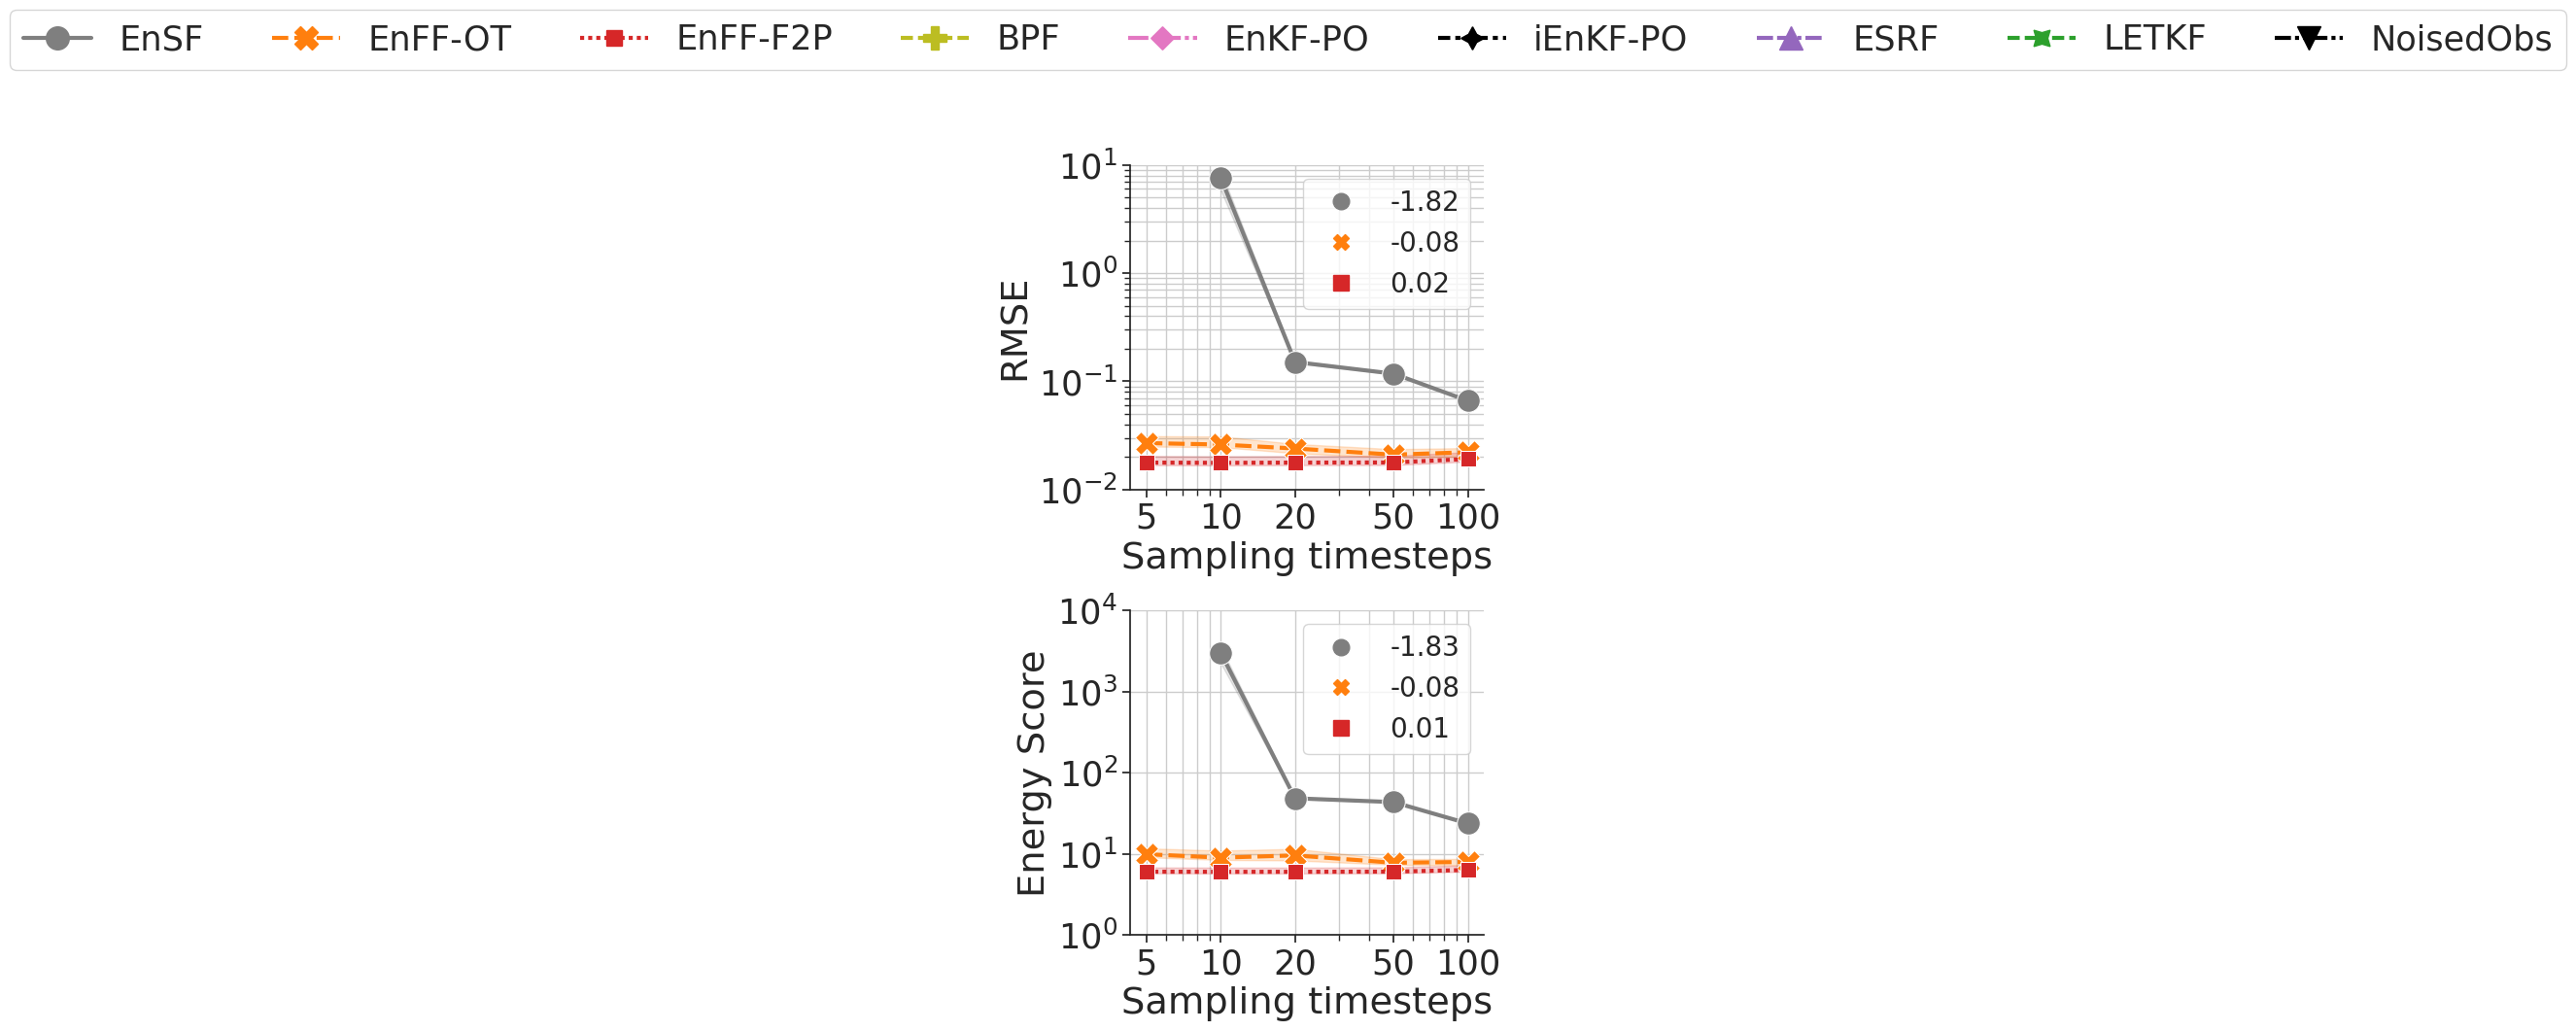

In [20]:
order2 = sorted(to_plot['hue'].unique(), key=dafm.plots.FILTER_ORDER.get)
order = [k for k, v in sorted(dafm.plots.FILTER_ORDER.items(), key=lambda x: x[1])]
plot = (
    sns.relplot(
        kind='line',
        estimator='mean',
        errorbar=('pi', 100),
        data=to_plot.to_pandas(),
        **{k: k if k != 'style' else 'hue' for k in to_plot.columns if k != 'alt_id'},
        hue_order=order,
        style_order=order,
        palette=dafm.plots.FILTER_PALETTE,
        markers=True,
        linewidth=3,
        markersize=17,
        aspect=1.3,
        facet_kws=dict(
            sharex=False,
            sharey=False,
        ),
    )
    .set_titles('')
    .set(
        xscale='log',
        xlabel='Sampling timesteps',
        # xlabel='Dimension',
        yscale='log',
        xticks=to_plot['x'].unique(),
        xticklabels=to_plot['x'].unique(),
        # xticklabels=[rf'${x} \times {x}$' for x in to_plot['x'].unique()],
    )
)
sns.move_legend(
    plot,
    loc='upper center',
    ncol=len(order),
    title='',
    bbox_to_anchor=(.455, 1.10),
    frameon=True,
    fancybox=True,
)

from matplotlib.lines import Line2D
import numpy as np
# 2) Lookup: (hue, row) -> slope
slope_map = {(r['hue'], r['row']): float(r['slope']) for r in slopes.to_dicts()}
marker_map = {
    'EnSF': 'o',
    'EnFF-OT': 'X',
    'EnFF-F2P': 's',
}
# 3) Add one legend per axis (per metric row)
for row_i, metric in enumerate(plot.row_names):
    ax = plot.axes[row_i, 0]  # one column in your current figure
    handles = []
    labels = []
    for h in order2:
        color = dafm.plots.FILTER_PALETTE.get(h, 'black')
        marker = marker_map.get(h, 'o')
        m = slope_map.get((h, metric), np.nan)
        label = f'{m:.2f}' if np.isfinite(m) else f'?'
        # Match line + marker style used in plot
        handle = Line2D(
            [0], [0],
            linestyle='None',
            color=color,
            marker=marker,
            linewidth=3,
            markersize=12,
        )
        handles.append(handle)
        labels.append(label)
    ax.legend(
        handles,
        labels,
        title='',
        loc='best',     # inside axis
        frameon=True,
        fancybox=True,
        fontsize=20,
        # title_fontsize=11,
    )
    
for (row, col, hue), _ in plot.facet_data():
    ax = plot.axes[row, col]
    ax.grid()
    ax.grid(which='minor')
    ax.tick_params(axis='both', which='minor', labelbottom=False)
    metric = plot.row_names[row]
    if metric == 'mean_rmse':
        ylabel = 'RMSE'
        # ax.set_ylim(.01, 10)
        # ax.set_ylim(.001, 3)
        ax.set_ylim(.01, 10)
    elif metric == 'mean_energy_score':
        ylabel = 'Energy Score'
        # ax.set_ylim(1, 1e4)
        ax.set_yticks([1, 10, 1e2, 1e3, 1e4])
        # ax.set_yticks([1, 10, 1e2, 1e3])
    else:
        raise ValueError(f'Unknown metric: {metric}')
    ax.set_ylabel(ylabel)

In [21]:
dafm.plots.save_all_subfigures(plot, 'Ablation')